# El Yangtsé exporta en julio 62 veces más microplástico que en enero

Un solo río, un solo mes: en julio de 2022 el Yangtsé mandó al mar 19.126 toneladas de microplástico — el 44% de todo su año y el 7,5% de lo que exportan juntos los ríos del planeta en doce meses. ¿Por qué se concentra tanto en tan poco tiempo?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Qin et al. (2026). *Hydroclimatic-driven pulse enrichment amplifies riverine microplastic export in developing countries*. **Science**

**DOI:** [10.1126/science.aeb4487](https://doi.org/10.1126/science.aeb4487)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-10-microplasticos-rios-pulsos/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/t90Hjo0PNq4)

## Un modelo global alimentado por 1.386 mediciones

El equipo reunió 1.386 mediciones de concentración de microplástico en 226 ríos (118 estudios según el paper; en la tabla contamos 116 referencias distintas), las armonizó a un mismo rango de tamaño (50–5.000 µm — porque una red de 300 µm deja pasar lo que una bomba con filtro de 50 µm atrapa) y entrenó con ellas un modelo de aprendizaje automático (R² = 0,72: buen ajuste al probarlo con datos que el modelo no había visto) que predice la concentración diaria en cada cuenca del mundo. Concentración × caudal = exportación: unas 263.000 toneladas en 2022 según el paper, muy por encima de la mayoría de estimaciones previas.

El paper es de pago. Lo que sí es público es su Supplementary: la salida **mensual** del modelo para 5.272 cuencas (Data S4 y S5, con el sistema de cuencas Global NEWS) y las 1.386 observaciones (Data S1). Con eso trabajamos. Dos advertencias antes de empezar: es un modelo, no una medición directa; y las series diarias con las que el paper define el «enriquecimiento por pulso» no están en el Supplementary, así que ese hallazgo lo miraremos con una lupa distinta — y más gruesa.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CUENCA_FOCO = 11            # basin_id (Global NEWS) del Yangtsé: lo identificamos por su flujo, 43.000 t/año en el SM
CUENCA_CONTRASTE = 1        # basin_id del Amazonas (la mayor cuenca por área)
UMBRAL_RHO = 0.5            # |ρ| a partir del cual llamamos "claro" al enriquecimiento o la dilución
MALLA_CORTE_UM = 100        # µm — corte de malla para la celda experimental
FUENTE = 'Fuente: Qin et al. (2026), Science | Datos: Supplementary Data S1, S4 y S5 (mismo DOI)'
COLOR_DATOS = '#2563EB'       # azul CaM — datos principales
COLOR_ALERTA = '#DC2626'      # rojo — pico / anomalía
COLOR_SECUNDARIO = '#059669'  # emerald
COLOR_REFERENCIA = '#D97706'  # amber — umbrales y referencias
COLOR_CORRELACION = '#7C3AED' # violeta — concentración / correlaciones
COLOR_CONTEXTO = '#BBBBBB'    # gris

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
PAPER = 'papers/2026-09-10-microplasticos-rios-pulsos'

# Estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos (descarga automática si no están en local)
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)
ARCHIVOS = ['export_mensual_cuenca.csv', 'concentracion_mensual_cuenca.csv', 'observaciones_rios.csv']
for nombre in ARCHIVOS:
    if not os.path.exists(f'datos/{nombre}'):
        urllib.request.urlretrieve(f'{BASE}/{PAPER}/datos/{nombre}', f'datos/{nombre}')

MESES = ['ene', 'feb', 'mar', 'abr', 'may', 'jun', 'jul', 'ago', 'sep', 'oct', 'nov', 'dic']
MESES_LBL = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

export = pd.read_csv('datos/export_mensual_cuenca.csv').set_index('basin_id')      # Data S5: t/mes
conc = pd.read_csv('datos/concentracion_mensual_cuenca.csv').set_index('basin_id') # Data S4: partículas/m³
obs = pd.read_csv('datos/observaciones_rios.csv')                                   # Data S1: 1.386 mediciones
export_m = export[[f'export_{m}' for m in MESES]].set_axis(MESES, axis=1)
conc_m = conc[[f'conc_{m}' for m in MESES]].set_axis(MESES, axis=1)

# Formato español: coma decimal, punto de miles
def es(x, dec=1):
    s = f'{x:,.{dec}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')

# ── Exportación anual por cuenca y reparto global ──
export_anual = export_m.sum(axis=1)
TOTAL = export_anual.sum()
positivas = export_anual[export_anual > 0].sort_values(ascending=False)
share_mensual_global = export_m.sum() / TOTAL * 100
cum_share = positivas.cumsum() / TOTAL * 100
def cuencas_para(pct):
    return int(np.searchsorted(cum_share.values, pct) + 1)
def gini(x):
    x = np.sort(np.asarray(x, dtype=float)); n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n

# ── Yangtsé ──
yz_export = export_m.loc[CUENCA_FOCO]
yz_conc = conc_m.loc[CUENCA_FOCO]
yz_total = yz_export.sum()
# Proxy de caudal: el paper calcula exportación = w · caudal · concentración, así que
# exportación ÷ concentración es proporcional al caudal (misma constante todo el año en una cuenca).
yz_q = yz_export / yz_conc

# ── ρ por cuenca: ¿los meses con más agua traen agua MÁS o MENOS cargada? ──
# MÉTRICA NUESTRA, no la del paper: Spearman entre concentración mensual y caudal-proxy mensual.
# El paper usa Pearson sobre series DIARIAS de concentración y escorrentía, y pondera por caudal.
# ρ > 0 = enriquecimiento (más agua, más concentrada); ρ < 0 = dilución.
comun = export_m.index.intersection(conc_m.index)
q_proxy = export_m.loc[comun] / conc_m.loc[comun]
ok = (conc_m.loc[comun] > 0).all(axis=1) & (export_anual.loc[comun] > 0)
rho = conc_m.loc[comun][ok].rank(axis=1).T.corrwith(q_proxy[ok].rank(axis=1).T).dropna()
cuartil = pd.qcut(export_anual.loc[rho.index], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
top20 = positivas.head(20).index
rho_top20 = rho.reindex(top20).dropna()
rho_logexp = stats.spearmanr(np.log10(export_anual.loc[rho.index]), rho)

print(f'Cuencas en Data S5: {len(export_anual)} · con exportación > 0: {len(positivas)} · con ρ evaluable: {len(rho)}')
print(f'Exportación global 2022 (suma S5): {es(TOTAL, 0)} t · el paper reporta ~263.000 t ({es((TOTAL / 263000 - 1) * 100)}%)')
print(f'Yangtsé (cuenca {CUENCA_FOCO}): {es(yz_total, 0)} t/año = {es(yz_total / TOTAL * 100)}% del total global')
print(f'  julio: {es(yz_export.jul, 0)} t = {es(yz_export.jul / yz_total * 100)}% de su año · '
      f'{es(yz_export.jul / TOTAL * 100)}% de la exportación mundial anual')
print(f'  jun–ago: {es(yz_export[["jun", "jul", "ago"]].sum() / yz_total * 100)}% del año · '
      f'may–oct: {es(yz_export[MESES[4:10]].sum() / yz_total * 100)}%')
print(f'  julio vs enero — concentración: {es(yz_conc.jul / yz_conc.ene, 2)}× ({es(yz_conc.ene, 0)} → {es(yz_conc.jul, 0)} partículas/m³) · '
      f'caudal-proxy: {es(yz_q.jul / yz_q.ene, 2)}× · exportación: {es(yz_export.jul / yz_export.ene)}×')
print(f'  ρ mensual Yangtsé: {es(rho[CUENCA_FOCO], 2)} · Amazonas (cuenca {CUENCA_CONTRASTE}): {es(rho[CUENCA_CONTRASTE], 2)}, '
      f'{es(export_anual[CUENCA_CONTRASTE], 0)} t/año, mes pico {export_m.loc[CUENCA_CONTRASTE].idxmax()} '
      f'({es(export_m.loc[CUENCA_CONTRASTE].max() / export_anual[CUENCA_CONTRASTE] * 100)}% del año)')
print()
print(f'Global — julio: {es(share_mensual_global.jul)}% · jun–ago: {es(share_mensual_global[["jun", "jul", "ago"]].sum())}% '
      f'(uniforme sería 25,0%)')
print(f'Reparto: top 10 = {es(cum_share.iloc[9])}% · top 20 = {es(cum_share.iloc[19])}% · '
      f'50% con {cuencas_para(50)} cuencas · 80% con {cuencas_para(80)} · 90% con {cuencas_para(90)}')
print(f'Por cuenca (n={len(positivas)}): mediana {es(positivas.median(), 2)} t/año · '
      f'IQR {es(positivas.quantile(0.25), 2)}–{es(positivas.quantile(0.75), 2)} · media {es(positivas.mean())} · Gini {es(gini(positivas), 3)}')
print()
print(f'ρ mensual (n={len(rho)}): mediana {es(rho.median(), 2)} · IQR {es(rho.quantile(0.25), 2)} a {es(rho.quantile(0.75), 2)} · '
      f'ρ>0: {es((rho > 0).mean() * 100)}% · ρ>{UMBRAL_RHO}: {es((rho > UMBRAL_RHO).mean() * 100)}% · ρ<−{UMBRAL_RHO}: {es((rho < -UMBRAL_RHO).mean() * 100)}%')
print(f'  exportación en cuencas con ρ>0: {es(export_anual.loc[rho[rho > 0].index].sum() / TOTAL * 100)}% del total')
print(f'  top 20: {(rho_top20 > 0).sum()} de {len(rho_top20)} con ρ>0 · mediana {es(rho_top20.median(), 2)} · '
      f'Spearman log(exportación) vs ρ: {es(rho_logexp.statistic, 3)} (p = {rho_logexp.pvalue:.1e})')
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    r = rho[cuartil == q]
    print(f'  {q} exportación (n={len(r)}): ρ mediana {es(r.median(), 2)} · ρ>0 en {es((r > 0).mean() * 100)}%')

Cuencas en Data S5: 5272 · con exportación > 0: 4964 · con ρ evaluable: 4953
Exportación global 2022 (suma S5): 255.971 t · el paper reporta ~263.000 t (-2,7%)
Yangtsé (cuenca 11): 43.079 t/año = 16,8% del total global
  julio: 19.126 t = 44,4% de su año · 7,5% de la exportación mundial anual
  jun–ago: 78,4% del año · may–oct: 91,1%
  julio vs enero — concentración: 7,09× (1.808 → 12.825 partículas/m³) · caudal-proxy: 8,69× · exportación: 61,7×
  ρ mensual Yangtsé: 0,60 · Amazonas (cuenca 1): -0,51, 10.100 t/año, mes pico abr (18,7% del año)

Global — julio: 15,1% · jun–ago: 35,7% (uniforme sería 25,0%)
Reparto: top 10 = 37,9% · top 20 = 49,0% · 50% con 22 cuencas · 80% con 152 · 90% con 350
Por cuenca (n=4964): mediana 0,92 t/año · IQR 0,18–6,67 · media 51,6 · Gini 0,949

ρ mensual (n=4953): mediana 0,42 · IQR -0,08 a 0,65 · ρ>0: 71,7% · ρ>0.5: 42,2% · ρ<−0.5: 11,2%
  exportación en cuencas con ρ>0: 50,3% del total
  top 20: 8 de 20 con ρ>0 · mediana -0,15 · Spearman log(exportación)

Aquí está. El Yangtsé, mes a mes.

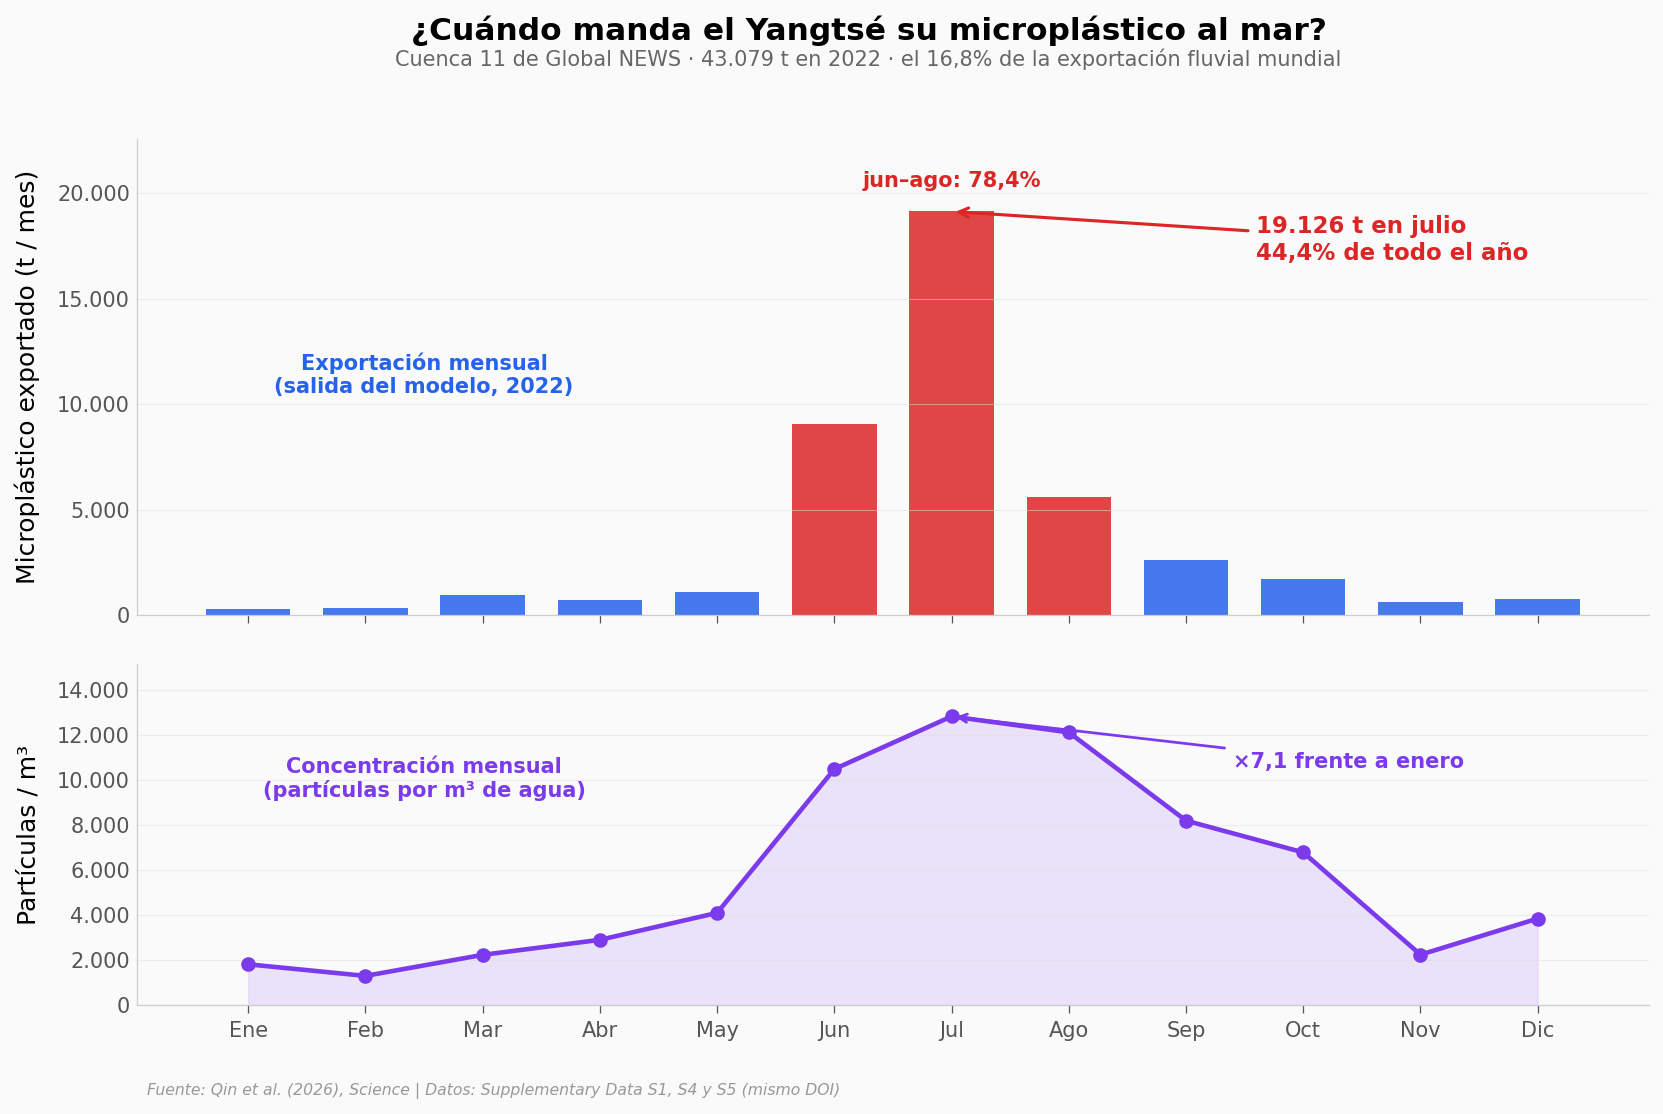

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True,
                               gridspec_kw={'height_ratios': [1.4, 1], 'hspace': 0.12})
x = np.arange(12)
lluvias = ['jun', 'jul', 'ago']
colores = [COLOR_ALERTA if m in lluvias else COLOR_DATOS for m in MESES]

# Panel 1: exportación mensual
ax1.bar(x, yz_export.values, color=colores, alpha=0.85, width=0.72)
share_jul = yz_export.jul / yz_total * 100
share_lluvias = yz_export[lluvias].sum() / yz_total * 100
ax1.annotate(f'{es(yz_export.jul, 0)} t en julio\n{es(share_jul)}% de todo el año',
             xy=(6, yz_export.jul), xytext=(8.6, yz_export.jul * 0.88),
             fontsize=11, fontweight='bold', color=COLOR_ALERTA, ha='left',
             arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))
ax1.text(6, yz_export.jul * 1.06, f'jun–ago: {es(share_lluvias)}%', ha='center',
         fontsize=10, color=COLOR_ALERTA, fontweight='bold')
ax1.text(1.5, yz_export.max() * 0.55, 'Exportación mensual\n(salida del modelo, 2022)',
         fontsize=10, color=COLOR_DATOS, fontweight='bold', ha='center')
ax1.set_ylabel('Microplástico exportado (t / mes)')
ax1.set_ylim(0, yz_export.max() * 1.18)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: es(v, 0)))

# Panel 2: concentración mensual
ax2.plot(x, yz_conc.values, color=COLOR_CORRELACION, lw=2.2, marker='o', ms=6, zorder=5)
ax2.fill_between(x, 0, yz_conc.values, color=COLOR_CORRELACION, alpha=0.12)
ax2.text(1.5, yz_conc.max() * 0.72, 'Concentración mensual\n(partículas por m³ de agua)',
         fontsize=10, color=COLOR_CORRELACION, fontweight='bold', ha='center')
ax2.annotate(f'×{es(yz_conc.jul / yz_conc.ene)} frente a enero', xy=(6, yz_conc.jul),
             xytext=(8.4, yz_conc.jul * 0.82), fontsize=10, color=COLOR_CORRELACION, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_CORRELACION, lw=1.3))
ax2.set_ylabel('Partículas / m³')
ax2.set_ylim(0, yz_conc.max() * 1.18)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: es(v, 0)))
ax2.set_xticks(x)
ax2.set_xticklabels(MESES_LBL)

fig.suptitle('¿Cuándo manda el Yangtsé su microplástico al mar?', fontsize=15, fontweight='bold', y=0.99)
fig.text(0.5, 0.945, f'Cuenca {CUENCA_FOCO} de Global NEWS · {es(yz_total, 0)} t en 2022 · '
         f'el {es(yz_total / TOTAL * 100)}% de la exportación fluvial mundial',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, 0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/yangtze_pulso_mensual.png', dpi=200, bbox_inches='tight')
plt.show()

Julio solo carga el 44,4% del año; junio, julio y agosto suman el 78,4%; entre mayo y octubre sale el 91,1%. Pero lo interesante no es que en la temporada de lluvias baje más agua — es cómo se multiplican dos cosas a la vez.

Entre enero y julio la concentración que estima el modelo sube 7,1 veces (de 1.808 a 12.825 partículas por m³) y el caudal sube 8,7 veces (aquí lo reconstruimos como exportación ÷ concentración, porque el paper calcula la exportación justo como el producto de ambos). Como exportación = concentración × caudal, sale 7,1 × 8,7 ≈ 62 veces más microplástico en julio que en enero. Si el agua de las lluvias solo diluyera, la concentración *bajaría* al subir el caudal y la exportación crecería mucho menos que el caudal. Eso es lo que el paper llama *pulse enrichment* — enriquecimiento por pulso: las crecidas coinciden con agua más cargada, no más limpia. El mecanismo que proponen es la escorrentía lavando plástico acumulado en ciudades, cultivos, carreteras y llanuras de inundación; es la interpretación de un modelo entrenado con observaciones, no un experimento.

A escala global el patrón se suaviza pero se ve: julio concentra el 15,1% de la exportación mundial y junio–agosto el 35,7%, frente al 25% que tocaría si fuera uniforme.

## ¿Es el Yangtsé una rareza?

El paper dice que la exportación global está «dominada por un pequeño número de grandes ríos» y que el Yangtsé es la mayor fuente individual. Contemos cuántas cuencas hacen falta para juntar la mitad.

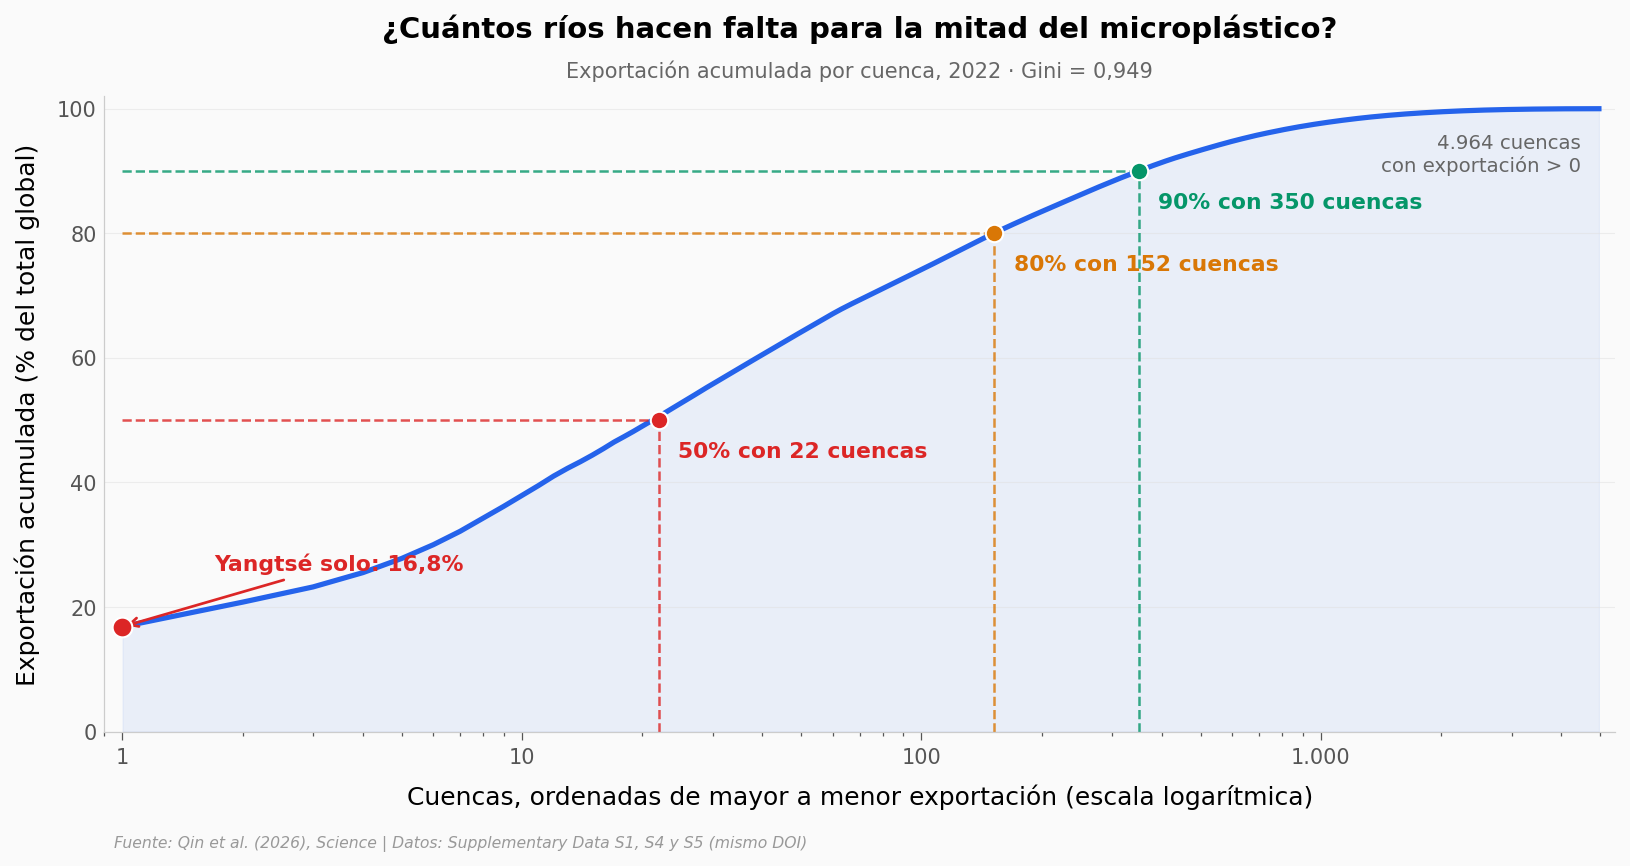

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))
rango = np.arange(1, len(positivas) + 1)
ax.plot(rango, cum_share.values, color=COLOR_DATOS, lw=2.5)
ax.fill_between(rango, 0, cum_share.values, color=COLOR_DATOS, alpha=0.08)
ax.set_xscale('log')

hitos = [(50, COLOR_ALERTA), (80, COLOR_REFERENCIA), (90, COLOR_SECUNDARIO)]
for pct, col in hitos:
    n = cuencas_para(pct)
    ax.plot([n, n], [0, pct], color=col, lw=1.2, ls='--', alpha=0.8)
    ax.plot([1, n], [pct, pct], color=col, lw=1.2, ls='--', alpha=0.8)
    ax.scatter([n], [pct], color=col, s=70, zorder=6, edgecolors='white', linewidths=1)
    ax.text(n * 1.12, pct - 6, f'{pct}% con {n} cuencas', fontsize=10.5, fontweight='bold', color=col)

yz_share = yz_total / TOTAL * 100
ax.scatter([1], [yz_share], color=COLOR_ALERTA, s=90, zorder=7, edgecolors='white', linewidths=1)
ax.annotate(f'Yangtsé solo: {es(yz_share)}%', xy=(1, yz_share), xytext=(1.7, yz_share + 9),
            fontsize=10.5, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))
ax.text(len(positivas) * 0.9, 96, f'{es(len(positivas), 0)} cuencas\ncon exportación > 0',
        fontsize=9.5, color='#666666', ha='right', va='top')

ax.set_xlabel('Cuencas, ordenadas de mayor a menor exportación (escala logarítmica)')
ax.set_ylabel('Exportación acumulada (% del total global)')
ax.set_ylim(0, 102)
ax.set_xlim(0.9, len(positivas) * 1.1)
ax.set_xticks([1, 10, 100, 1000])
ax.set_xticklabels(['1', '10', '100', '1.000'])
ax.set_title('¿Cuántos ríos hacen falta para la mitad del microplástico?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Exportación acumulada por cuenca, 2022 · Gini = {es(gini(positivas), 3)}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/concentracion_cuencas.png', dpi=200, bbox_inches='tight')
plt.show()

El Yangtsé (cuenca 11 de Global NEWS — la identificamos por su flujo: 43.079 t frente a las 43.000 t que el Supplementary le atribuye, +0,2%) aporta el 16,8% de la exportación mundial. Las 10 primeras cuencas suman el 37,9%; con 22 se pasa el 50%, con 152 el 80% y con 350 el 90%. Al otro lado hay 4.964 cuencas con exportación mayor que cero, y la mediana exporta 0,92 toneladas al año (la mitad central de las cuencas cae entre 0,18 y 6,67 t/año). El índice de Gini es 0,949, donde 0 sería un reparto uniforme y 1 una sola cuenca exportándolo todo.

## ¿Y el pulso, es de todos los ríos?

Aquí toca ser honestos con la lupa. El paper define el enriquecimiento por pulso con series **diarias** de concentración y escorrentía, y reporta que ~70% del caudal global lo exhibe. El Supplementary solo trae valores mensuales. Lo que sí podemos calcular, cuenca por cuenca, es otra cosa: la correlación de Spearman entre la concentración mensual y nuestro caudal reconstruido. ρ > 0 significa que los meses con más agua traen agua más cargada (enriquecimiento); ρ < 0, que la diluyen. No es la métrica del paper, y ni la confirma ni la refuta: es una lupa mensual sobre un fenómeno diario.

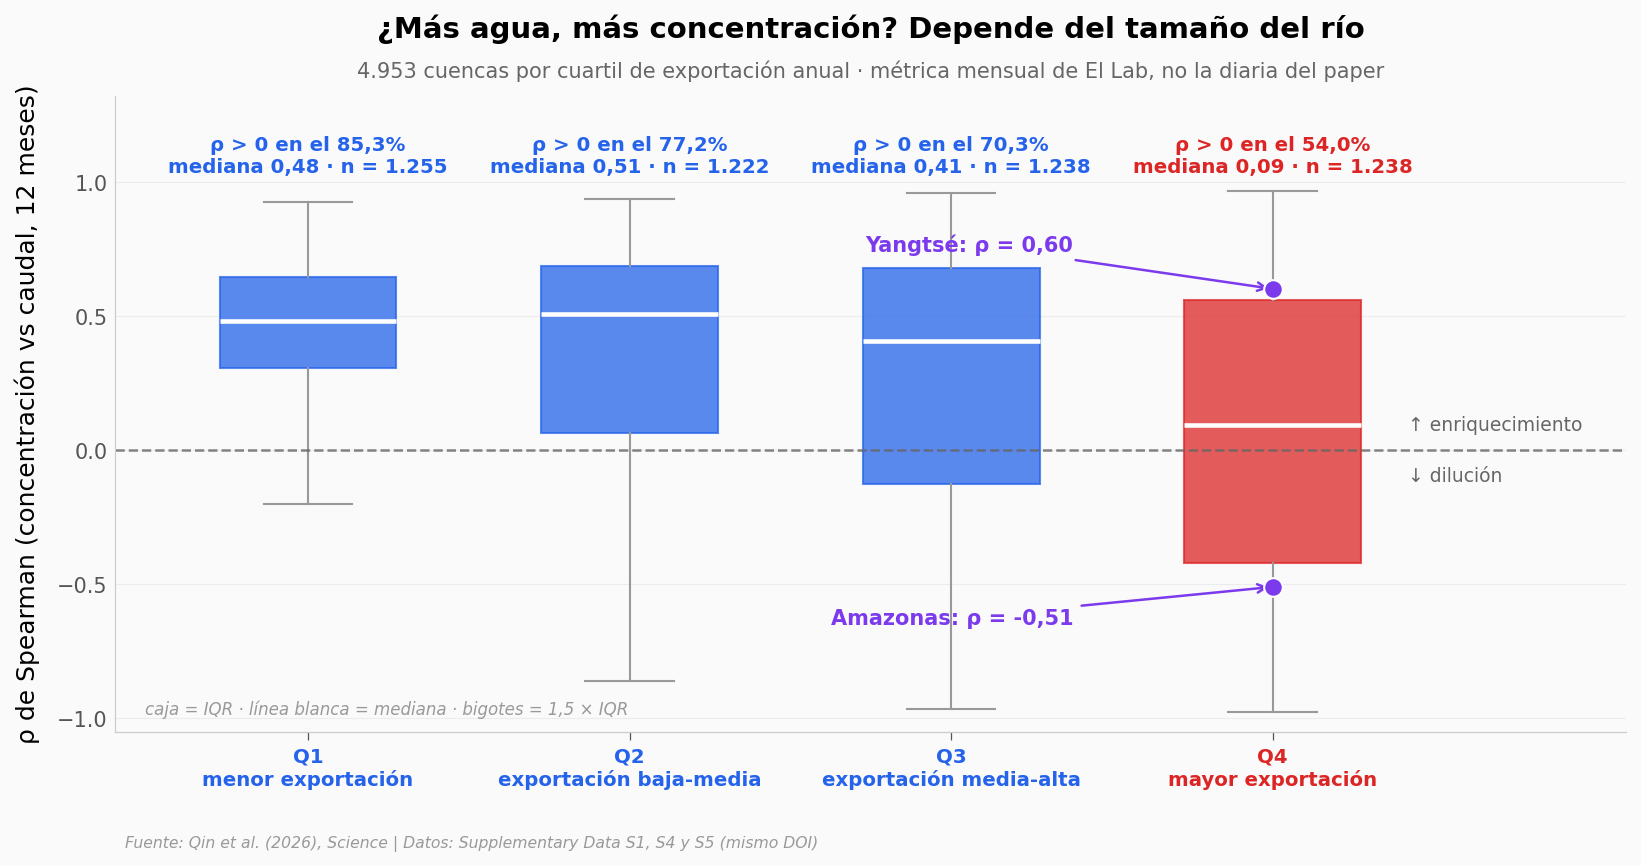

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))
grupos = ['Q1', 'Q2', 'Q3', 'Q4']
etiquetas = ['Q1\nmenor exportación', 'Q2\nexportación baja-media', 'Q3\nexportación media-alta', 'Q4\nmayor exportación']
colores_q = [COLOR_DATOS, COLOR_DATOS, COLOR_DATOS, COLOR_ALERTA]
datos_q = [rho[cuartil == q].values for q in grupos]
posiciones = [0, 1, 2, 3]

bp = ax.boxplot(datos_q, positions=posiciones, widths=0.55, showfliers=False, patch_artist=True,
                medianprops=dict(color='white', lw=2.2), whiskerprops=dict(color='#999999'),
                capprops=dict(color='#999999'))
for caja, col in zip(bp['boxes'], colores_q):
    caja.set(facecolor=col, alpha=0.75, edgecolor=col)
for pos, q, col in zip(posiciones, grupos, colores_q):
    r = rho[cuartil == q]
    ax.text(pos, 1.02, f'ρ > 0 en el {es((r > 0).mean() * 100)}%\nmediana {es(r.median(), 2)} · n = {es(len(r), 0)}',
            ha='center', va='bottom', fontsize=9.5, color=col, fontweight='bold')

ax.axhline(0, color='#666666', lw=1.2, ls='--', alpha=0.8)
ax.text(3.42, 0.06, '↑ enriquecimiento', fontsize=9, color='#666666', va='bottom')
ax.text(3.42, -0.06, '↓ dilución', fontsize=9, color='#666666', va='top')

# Dos cuencas grandes con signo opuesto
for cid, nombre, dx in [(CUENCA_FOCO, 'Yangtsé', 0.62), (CUENCA_CONTRASTE, 'Amazonas', 0.62)]:
    ax.scatter([3], [rho[cid]], color=COLOR_CORRELACION, s=80, zorder=7, edgecolors='white', linewidths=1)
    ax.annotate(f'{nombre}: ρ = {es(rho[cid], 2)}', xy=(3, rho[cid]), xytext=(3 - dx, rho[cid] + (0.14 if rho[cid] > 0 else -0.14)),
                fontsize=10, fontweight='bold', color=COLOR_CORRELACION, ha='right',
                arrowprops=dict(arrowstyle='->', color=COLOR_CORRELACION, lw=1.2))

ax.set_xticks(posiciones)
ax.set_xticklabels(etiquetas, fontsize=9.5, fontweight='bold')
for tick, col in zip(ax.get_xticklabels(), colores_q):
    tick.set_color(col)
ax.set_ylabel('ρ de Spearman (concentración vs caudal, 12 meses)')
ax.set_ylim(-1.05, 1.32)
ax.set_xlim(-0.6, 4.1)
ax.text(0.02, 0.02, 'caja = IQR · línea blanca = mediana · bigotes = 1,5 × IQR', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='left', va='bottom', style='italic')
ax.set_title('¿Más agua, más concentración? Depende del tamaño del río', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{es(len(rho), 0)} cuencas por cuartil de exportación anual · métrica mensual de El Lab, no la diaria del paper',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rho_por_cuartil.png', dpi=200, bbox_inches='tight')
plt.show()

En 4.953 cuencas evaluables, la ρ mediana es 0,42 (la mitad central va de −0,08 a 0,65): el 71,7% tiene ρ > 0, el 42,2% pasa de 0,5 y solo el 11,2% diluye con claridad (ρ < −0,5). Pero el signo cambia con el tamaño. En el cuartil de menor exportación, el 85,3% de las cuencas enriquece (ρ mediana 0,48); en el de mayor exportación, el 54,0% (ρ mediana 0,09). Entre las 20 cuencas que más exportan, 8 tienen ρ > 0 y la mediana es −0,15. El Amazonas es el caso de libro de la dilución: ρ = −0,51, sus meses de más agua traen agua menos cargada. El Yangtsé va al revés: ρ = 0,60. La correlación entre el logaritmo de la exportación y ρ es −0,22 — débil, pero de signo claro.

Insistimos: ese 71,7% de cuencas **no es** el «~70% del caudal» del paper. Se parecen de casualidad: una métrica cuenta cuencas con datos mensuales y sin ponderar; la otra, caudal con series diarias. Si ponderamos por exportación, las cuencas con ρ > 0 cargan el 50,3% del total — y ahí el parecido se esfuma.

## ¿Qué tan anómalo es el Yangtsé?

Una cuenca mediana exporta menos de una tonelada al año. El Yangtsé, 43.079.

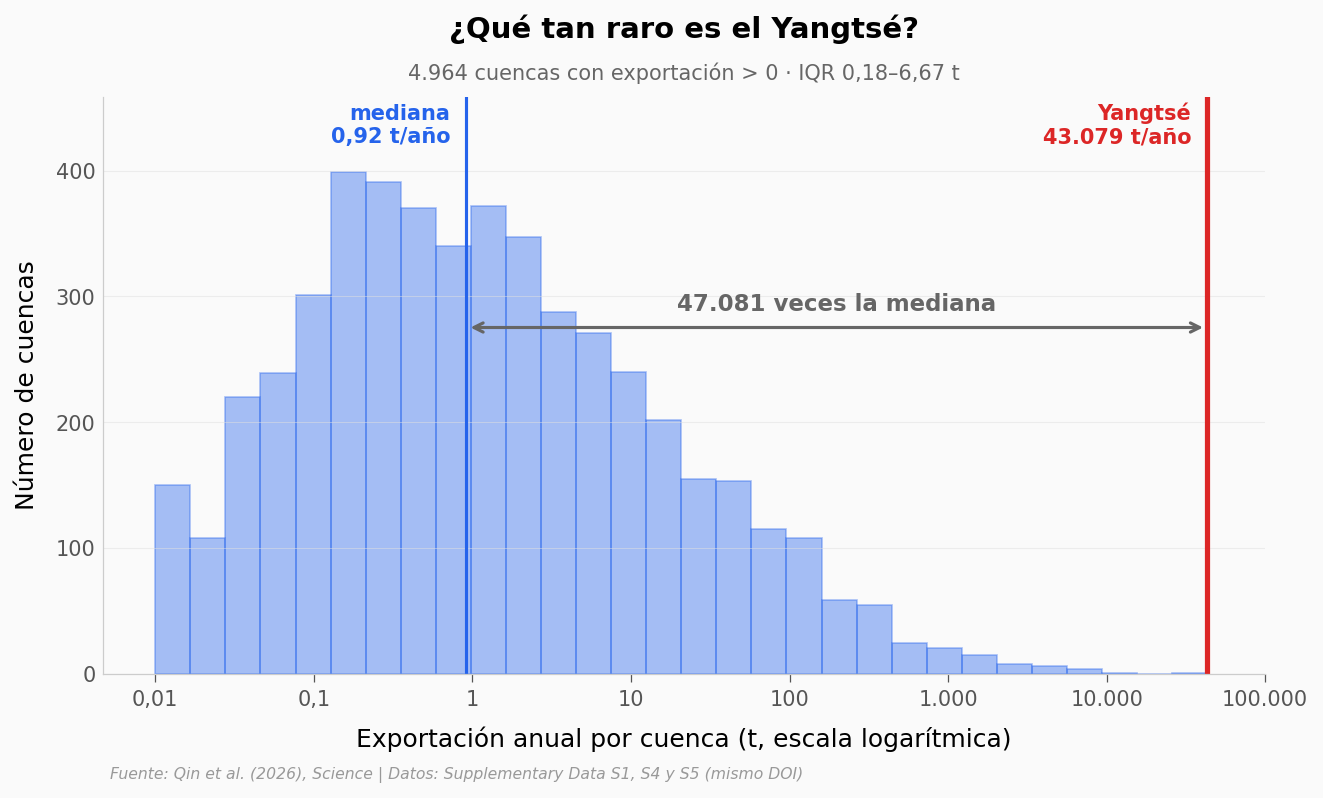

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
log_export = np.log10(positivas.values)
n, bins, patches = ax.hist(log_export, bins=30, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

mediana = positivas.median()
ratio = yz_total / mediana
ax.axvline(np.log10(mediana), color=COLOR_DATOS, linewidth=1.5)
ax.axvline(np.log10(yz_total), color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(np.log10(yz_total), y_max * 0.6), xytext=(np.log10(mediana), y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((np.log10(yz_total) + np.log10(mediana)) / 2, y_max * 0.63,
        f'{es(ratio, 0)} veces la mediana', ha='center', fontsize=11, fontweight='bold', color='#666666')
ax.text(np.log10(mediana) - 0.1, y_max * 0.92, f'mediana\n{es(mediana, 2)} t/año', ha='right',
        fontsize=10, fontweight='bold', color=COLOR_DATOS)
ax.text(np.log10(yz_total) - 0.1, y_max * 0.92, f'Yangtsé\n{es(yz_total, 0)} t/año', ha='right',
        fontsize=10, fontweight='bold', color=COLOR_ALERTA)

ticks = np.arange(-2, 6)
ax.set_xticks(ticks)
ax.set_xticklabels(['0,01', '0,1', '1', '10', '100', '1.000', '10.000', '100.000'])
ax.set_xlabel('Exportación anual por cuenca (t, escala logarítmica)')
ax.set_ylabel('Número de cuencas')
ax.set_title('¿Qué tan raro es el Yangtsé?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'{es(len(positivas), 0)} cuencas con exportación > 0 · IQR {es(positivas.quantile(0.25), 2)}–{es(positivas.quantile(0.75), 2)} t',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_export_cuencas.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los ríos exportaron unas 263.000 t de microplástico al mar en 2022 | ✅ | La suma de Data S5 da 255.971 t: un 2,7% por debajo de las ~263.000 t del abstract y un 1,6% por debajo de las 260.000 t que redondea el Supplementary. El redondeo de los valores no explica la diferencia (sumar 5.272 filas redondeadas a 2 decimales cambia el total en menos de 1 t) y el Supplementary no dice a qué se debe. Es la salida de un modelo (R² = 0,72), no una medición |
| El Yangtsé es la mayor fuente individual | ✅ | 43.079 t, el 16,8% del total. La cuenca 11 coincide con las 43.000 t que el SM asigna al Yangtsé (+0,2%) |
| La exportación global está dominada por pocos ríos | ✅ | 22 cuencas suman el 50%, 152 el 80% y 350 el 90%; Gini = 0,949 sobre 4.964 cuencas con exportación > 0 |
| En los ríos de mayor exportación, la mayor parte sale en la temporada de lluvias | ✅ | Yangtsé: 78,4% en jun–ago. En las 20 cuencas top, el mes pico carga una mediana del 16,9% (la mitad central entre 13,2% y 21,6%) y los tres meses top el 46,0% (la mitad central entre 35,1% y 51,6%). Global: 35,7% en jun–ago |
| ~70% del caudal global muestra enriquecimiento por pulso | ⚠️ | No reproducible: requiere las series diarias, que no están en el Supplementary. Nuestro proxy mensual da ρ > 0 en el 71,7% de las cuencas (50,3% de la exportación), pero es otra métrica y no confirma la cifra |
| El 96% de la exportación viene del Sur Global; Sudeste y Este de Asia aportan más de la mitad | ⚠️ | No verificable: el Supplementary no trae el mapa cuenca → país. Lo citamos tal cual del paper |
| Las crecidas por lluvia disparan picos de concentración | ⚠️ | Es la asociación del paper (regresión, Fig. S5). En el Yangtsé la concentración sube 7,1× de enero a julio a la vez que el caudal; sin datos diarios ni de lluvia, aquí solo vemos coincidencia estacional |
| El método de muestreo cambia la concentración medida en órdenes de magnitud | ✅ | 1.386 observaciones: bomba (malla mediana 53 µm) 911,6 vs red (300 µm) 4,8 partículas/m³ en crudo, 189× (d de Cohen en log10 = 1,51, Mann-Whitney p = 6×10⁻¹⁰⁹); armonizado a 50–5.000 µm queda 16,8× (d = 0,74). ρ malla–log(concentración) = −0,62 (n = 1.351) |

> **Limitaciones:** todo lo mensual es salida de un modelo, no medición. La ρ por cuenca es una métrica de El Lab, mensual y sin ponderar por caudal — no equivale al enriquecimiento por pulso del paper, que se define sobre series diarias. Identificamos el Yangtsé por coincidencia de flujo con el SM, no por un nombre en la tabla. 11 cuencas están en Data S5 pero no en S4 (107 t, 0,04% del total) y quedan fuera de la ρ. En Data S1 corregimos 17 filas del río Aras con años 2023–2039 (autorrelleno de Excel → año vacío; las 19 filas de ese río siguen el mismo patrón, así que las dos que quedaron en 2021 y 2022 podrían ser el mismo artefacto — la columna de año no entra en ningún cálculo) y 5 filas del río Suquía con longitud y latitud intercambiadas. El paper es de pago: lo que citamos de su cuerpo viene del *Structured Abstract* y del Supplementary. La proyección de que las lluvias extremas *podrían* intensificar los pulsos es del paper y no la tocamos aquí.

## Ahora tú

1. **¿Cómo se reparte el año en otra cuenca grande?** Cambia `CUENCA_FOCO` por uno de los `basin_id` de `positivas.head(20).index` y vuelve a correr la gráfica principal. ¿Cuál concentra más en un solo mes?
2. **¿Cuántas cuencas hacen falta para el 95% o el 99%?** Prueba `cuencas_para(95)` y `cuencas_para(99)`. ¿Sigue pareciendo «pocos ríos»?
3. **¿Cuánto cambia la concentración medida según la malla?** La celda de abajo separa las 1.386 observaciones por método (red vs bomba) y por `MALLA_CORTE_UM`. Prueba con 300 µm — la malla más común en redes.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto cambia la concentración medida según cómo se muestrea?
validas = obs[obs['conc_items_m3'] > 0].copy()
validas['log_conc'] = np.log10(validas['conc_items_m3'])

print(f'Observaciones (Data S1): {len(obs)} · ríos distintos: {obs["rio"].nunique()} · '
      f'referencias distintas: {obs["referencia"].nunique()} · con concentración > 0: {len(validas)}')
print()
for etiqueta, columna in [('crudo', 'conc_items_m3'), ('armonizado 50–5.000 µm', 'conc_armonizada_items_m3')]:
    red = obs.loc[obs['metodo'] == 'Net', columna].dropna()
    bomba = obs.loc[obs['metodo'] == 'Pump', columna].dropna()
    p = stats.mannwhitneyu(bomba, red).pvalue
    # Tamaño del efecto en log10 (la variable abarca ~6 órdenes de magnitud; en escala cruda d sería engañoso)
    lr, lb = np.log10(red[red > 0]), np.log10(bomba[bomba > 0])
    sd_pool = np.sqrt(((len(lr) - 1) * lr.var(ddof=1) + (len(lb) - 1) * lb.var(ddof=1)) / (len(lr) + len(lb) - 2))
    d = (lb.mean() - lr.mean()) / sd_pool
    print(f'{etiqueta}: red (n={len(red)}, malla mediana {es(obs.loc[obs.metodo == "Net", "malla_um"].median(), 0)} µm) '
          f'mediana {es(red.median(), 2)} · bomba (n={len(bomba)}, malla mediana '
          f'{es(obs.loc[obs.metodo == "Pump", "malla_um"].median(), 0)} µm) mediana {es(bomba.median(), 2)} '
          f'partículas/m³ · cociente {es(bomba.median() / red.median())}× · d de Cohen (log10) = {es(d, 2)} · Mann-Whitney p = {p:.1e}')

con_malla = validas.dropna(subset=['malla_um'])
sp = stats.spearmanr(con_malla['malla_um'], con_malla['log_conc'])
print(f'\nSpearman malla (µm) vs log10(concentración cruda): ρ = {es(sp.statistic, 3)} (n = {len(con_malla)}, p = {sp.pvalue:.1e})')

fina = con_malla[con_malla['malla_um'] <= MALLA_CORTE_UM]['conc_items_m3']
gruesa = con_malla[con_malla['malla_um'] > MALLA_CORTE_UM]['conc_items_m3']
print(f'Malla ≤ {MALLA_CORTE_UM} µm (n={len(fina)}): mediana {es(fina.median(), 2)} · '
      f'malla > {MALLA_CORTE_UM} µm (n={len(gruesa)}): mediana {es(gruesa.median(), 2)} · '
      f'cociente {es(fina.median() / gruesa.median())}×')

Observaciones (Data S1): 1386 · ríos distintos: 226 · referencias distintas: 116 · con concentración > 0: 1351

crudo: red (n=763, malla mediana 300 µm) mediana 4,82 · bomba (n=620, malla mediana 53 µm) mediana 911,57 partículas/m³ · cociente 189,1× · d de Cohen (log10) = 1,51 · Mann-Whitney p = 6.4e-109
armonizado 50–5.000 µm: red (n=763, malla mediana 300 µm) mediana 63,88 · bomba (n=620, malla mediana 53 µm) mediana 1.070,40 partículas/m³ · cociente 16,8× · d de Cohen (log10) = 0,74 · Mann-Whitney p = 1.6e-42

Spearman malla (µm) vs log10(concentración cruda): ρ = -0,624 (n = 1351, p = 1.8e-146)
Malla ≤ 100 µm (n=706): mediana 910,79 · malla > 100 µm (n=645): mediana 3,57 · cociente 255,1×


---

## Fuentes

**Paper**: [Hydroclimatic-driven pulse enrichment amplifies riverine microplastic export in developing countries](https://doi.org/10.1126/science.aeb4487)  
*Science, 2026-09-10 · paywall*

**Supplementary Material**: [Data S1 to S6 for "Hydroclimatic-driven pulse enrichment amplifies riverine microplastic export in developing countries" (science.aeb4487_data_s1_to_s6.xlsx)](https://www.science.org/doi/suppl/10.1126/science.aeb4487/suppl_file/science.aeb4487_data_s1_to_s6.zip)  
*Science, 2026-09-10*

**Supplementary Material**: [Supplementary Materials (Materials and Methods, Figs. S1–S15, Table S1) for "Hydroclimatic-driven pulse enrichment amplifies riverine microplastic export in developing countries"](https://www.science.org/doi/suppl/10.1126/science.aeb4487/suppl_file/science.aeb4487_sm.pdf)  
*Science, 2026-09-10*

*44 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab). Los CSV de este notebook son los Data S1, S4 y S5 del Supplementary (mismo DOI), convertidos de XLSX a CSV; las columnas `malla_um`, `anio` y `region_aprox` de las observaciones las añadió El Lab.*